In [18]:
import numpy as np
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [19]:
import os
os.chdir('C:\\Users\\BAPS\\Downloads')
print(os.getcwd())



C:\Users\BAPS\Downloads


In [20]:
df=pd.read_csv('DataCoSupplyChainDataset.csv',encoding= 'latin-1')

In [21]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')

sns.set_palette("viridis")

# Generate 5 colors from Viridis
viridis_colors = cm.viridis(np.linspace(0, 1, 5))

# Define colors
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]

# Custom palette
custom_palette = viridis_colors

In [22]:
# Overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))
print(df.columns.tolist())

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

**EDA**

In [23]:
# Data cleaning

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Customer City',
    'Product Status',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Drop columns
df = df.drop(columns=columns_to_drop, errors='ignore')

# Remove cancelled shipments
df = df[df['Delivery Status'] != 'Shipping Canceled']

# Convert date columns
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Check dataset after cleaning
print('rows, cols:', df.shape)

print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (180519, 21)

Missing values (top 5):
shipping date (DateOrders)    108963
order date (DateOrders)        71103
Type                               0
Product Price                      0
Product Name                       0
dtype: int64


In [24]:
# value counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f"\n{col} value counts:")
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    49883
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    56618
3    28765
6    28723
4    28513
5    28163
0     5080
1     4657
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    107752
2     35216
1     27814
0      9737
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery        98977
Advance shipping     41592
Shipping on time     32196
Shipping canceled     7754
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        111146
Puerto Rico     69373
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       93504
Corporate      54789
Home Office    32226
Name: count, dtype: int64

Order Status value c

In [25]:
# calculating order processing time and delay
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']

df['Is_Delayed'] = df['Delay'] > 0

df['order_month'] = df['order date (DateOrders)'].dt.month

df['order_day'] = df['order date (DateOrders)'].dt.day_name()

df['order_hour'] = df['order date (DateOrders)'].dt.hour

df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,109416,180519.000000,180519.000000,180519.000000,180519.000000,71556,20957.000000,20957.000000,109416.000000,109416.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,2016-06-18 06:20:26.005703424,0.120647,203.772096,21.974989,141.232550,2016-06-12 01:39:45.431829760,4.251610,0.969461,6.247258,11.501407
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2015-01-13 00:20:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,2015-09-25 17:40:00,0.080000,119.980003,7.000000,50.000000,2015-09-11 18:59:45,3.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,2016-06-18 21:50:30,0.270000,199.919998,31.520000,59.990002,2016-06-08 16:42:00,4.000000,1.000000,6.000000,12.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,2017-02-28 14:29:00,0.360000,299.950012,64.800003,199.990005,2017-03-05 02:28:00,6.000000,2.000000,9.000000,18.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623722,1.374449,104.433526,120.043670,0.497664,NaN,0.466796,132.273077,104.433526,139.732492,NaN,1.487561,1.492017,3.405052,6.919911


In [26]:
df['Is_Delayed'].value_counts()

Is_Delayed
False    166712
True      13807
Name: count, dtype: int64

In [27]:
df.columns


Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Name', 'Customer Country',
       'Customer Segment', 'Department Name', 'order date (DateOrders)',
       'Order Item Profit Ratio', 'Sales', 'Order Profit Per Order',
       'Order Region', 'Order Status', 'Product Name', 'Product Price',
       'shipping date (DateOrders)', 'Shipping Mode', 'Order Processing Time',
       'Delay', 'Is_Delayed', 'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [28]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 180519, dtype: bool

In [29]:
# Profitability Flag based on Order Profit Per Order
df['Profitability Flag'] = np.where(
    df['Order Profit Per Order'] > 0,
    'Profit',
    np.where(
        df['Order Profit Per Order'] < 0,
        'Loss',
        'Break-even'
    )
)

df['Profitability Flag'].value_counts()

Profitability Flag
Profit        145558
Loss           33784
Break-even      1177
Name: count, dtype: int64

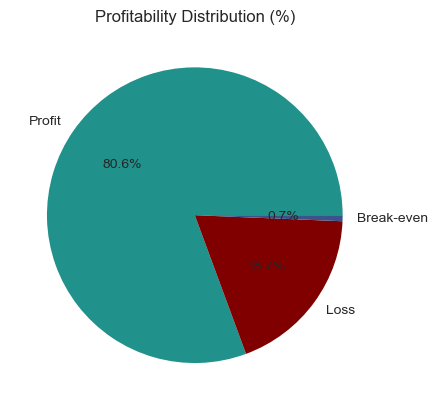

In [30]:
# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [31]:
def format_func(value):
    if value >= 1e6:
        return f'${value/1e6:.1f}M'
    elif value >= 1e3:
        return f'${value/1e3:.1f}K'
    else:
        return f'${value:,.0f}'


delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)

metrics['Late Deliveries'] = len(delayed_df)

metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)

metrics['On Time Delivery %'] = (
    (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
)

metrics['Late Delivery %'] = (
    float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
)

metrics['Total Profit'] = format_func(
    df.loc[
        df['Order Profit Per Order'] > 0,
        'Order Profit Per Order'
    ].sum()
)

metrics['Total Loss due to delays'] = format_func(
    df.loc[
        df['Delay'] > 0,
        'Order Profit Per Order'
    ].sum()
)

print('\n--- Business KPIs ---\n')

for k, v in metrics.items():
    if isinstance(v, float):
        print(f'{k}: {v:.1f}%')
    else:
        print(f'{k}: {v}')


--- Business KPIs ---

Total Orders: 180519
Late Deliveries: 13807
90% Delay (days): 3.0%
On Time Delivery %: 92.4%
Late Delivery %: 7.6%
Total Profit: $7.9M
Total Loss due to delays: $290.5K


**PROFITABILITY VS DELIVERY TIME ANALYSIS**

In [32]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order']
    .agg(
        mean_profit='mean',
        total_profit='sum',
        order_count='count'
    )
    .reset_index()
)

profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2.0,22.560225,33005.609883,1463
1,-1.0,26.966950,56846.330199,2108
2,0.0,22.010380,78775.150152,3579
3,1.0,21.970062,130612.019657,5945
4,2.0,18.491769,101186.959983,5472
5,3.0,25.041922,27496.030094,1098
6,4.0,24.164102,31220.020020,1292


In [35]:
delay_distribution = (
    df['Delay']
    .value_counts(normalize=True)
    .sort_index() * 100
)
delay_distribution

Delay
-2.0     6.980961
-1.0    10.058692
 0.0    17.077826
 1.0    28.367610
 2.0    26.110607
 3.0     5.239300
 4.0     6.165005
Name: proportion, dtype: float64

In [38]:
delay_distribution = delay_distribution.reset_index()


Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2.0,22.6,33005.6,1463
1,-1.0,27.0,56846.3,2108
2,0.0,22.0,78775.2,3579
3,1.0,22.0,130612.0,5945
4,2.0,18.5,101187.0,5472
5,3.0,25.0,27496.0,1098
6,4.0,24.2,31220.0,1292



Delay Distribution (%):


,Delay_Days,Percentage
0,-2.0,6.980961
1,-1.0,10.058692
2,0.0,17.077826
3,1.0,28.367610
4,2.0,26.110607
5,3.0,5.239300
6,4.0,6.165005


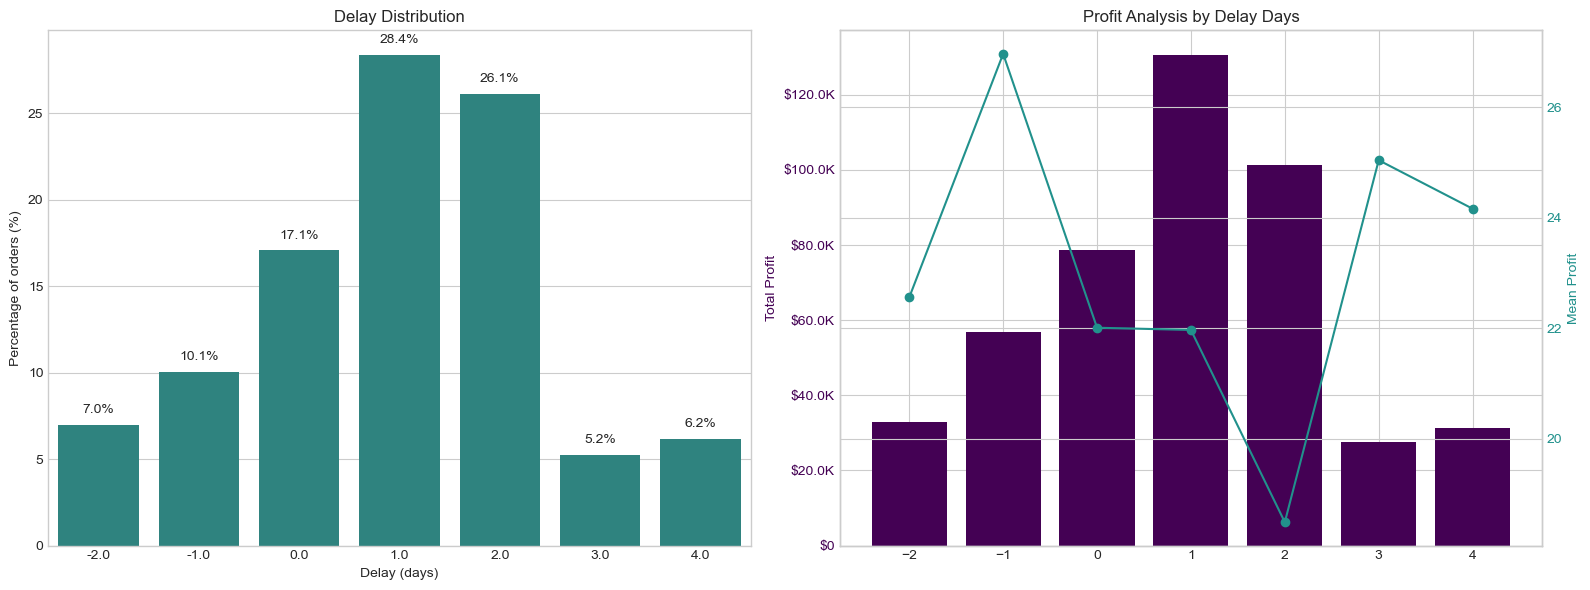

In [41]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('Percentage of orders (%)')

# Percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )


# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel('Total Profit', color=primary_color)

ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.tick_params(
    axis='y',
    labelcolor=primary_color
)


# Mean Profit on secondary Y-axis
ax3 = ax2.twinx()

ax3.set_xlabel('Delay Days')
ax3.set_ylabel('Mean Profit', color=accent_color)

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    label='Mean Profit',
    color=accent_color
)

ax3.tick_params(
    axis='y',
    labelcolor=accent_color
)


# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'${value / 1e6:.1f}M'
    elif value >= 1e3:
        return f'${value / 1e3:.1f}K'
    else:
        return f'${value:,.0f}'


# Apply formatting to Total Profit axis
from matplotlib.ticker import FuncFormatter

ax2.yaxis.set_major_formatter(FuncFormatter(format_func))

ax2.set_title('Profit Analysis by Delay Days')

plt.tight_layout()
plt.show()

**BottleNeck Detection**

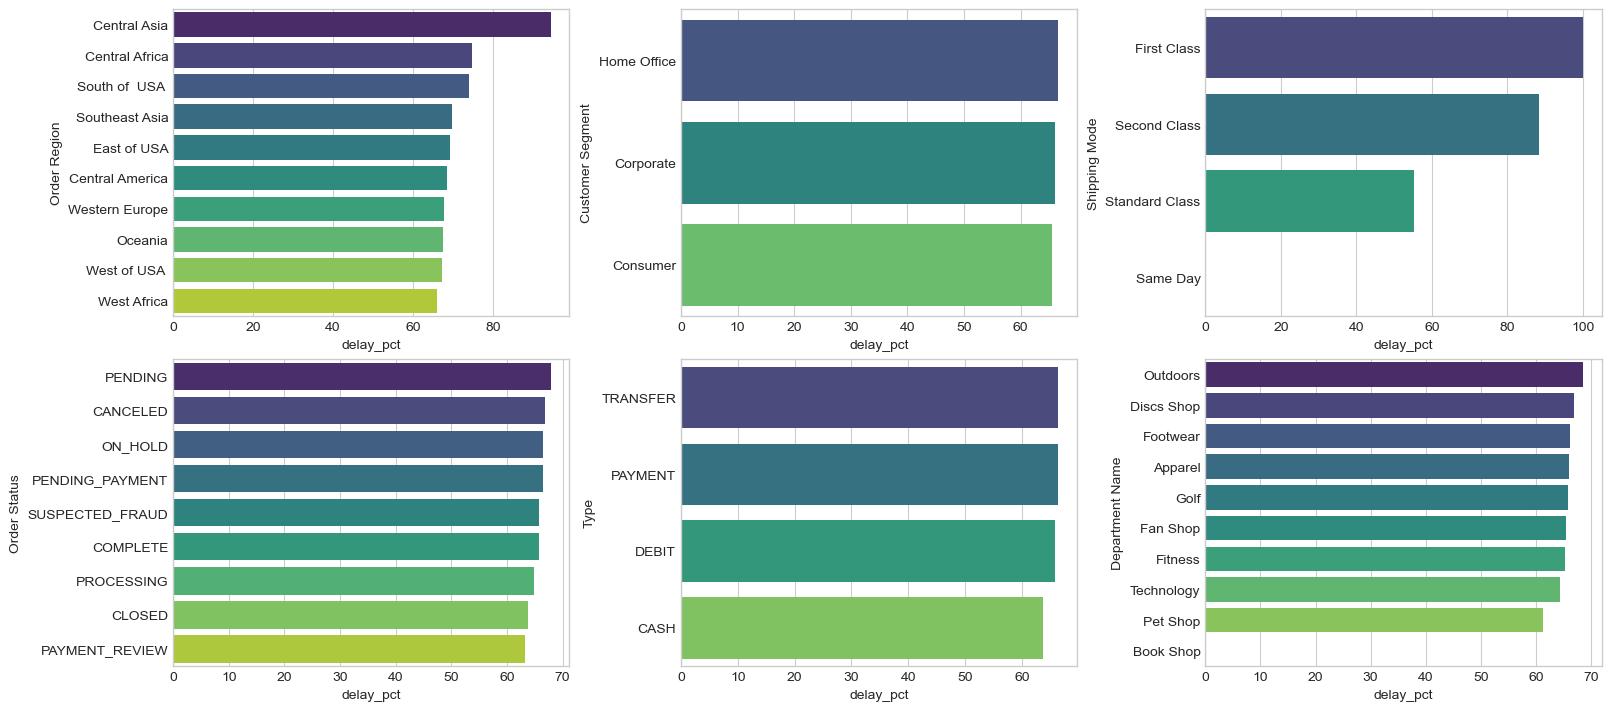

In [42]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders'] * 100
    )

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

**ROOT CAUSE ANALYSIS**

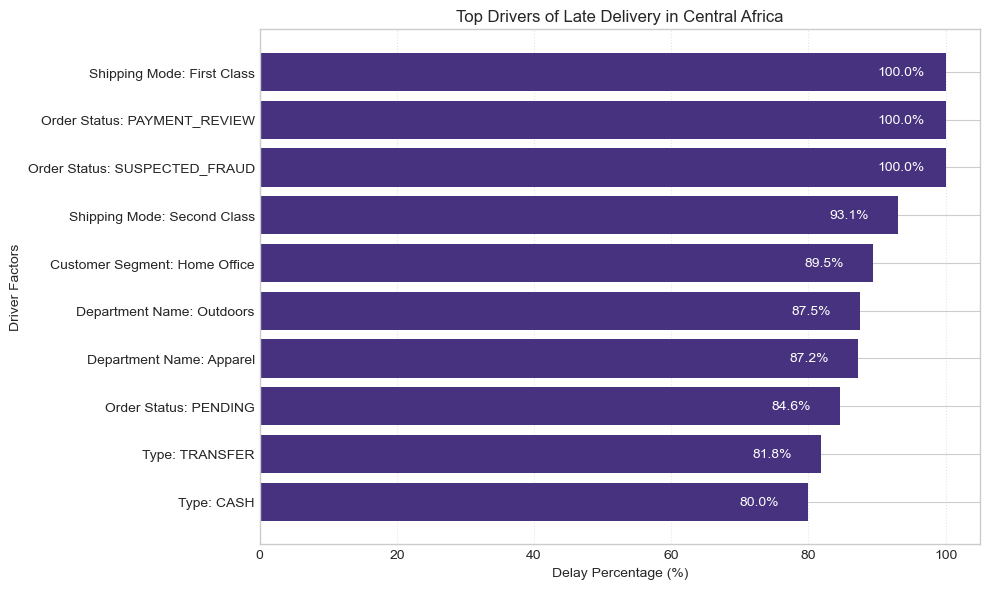

In [54]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):

    # Filter data for selected region
    df_region = df[df['Order Region'] == region].copy()

    # Factors to analyze
    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    # Store results for all factors
    all_factors = []

    # Calculate delay percentage for each factor
    for factor in drivers:

        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        # Calculate delay percentage
        temp['delay_pct'] = (
            temp['late_orders'] /
            temp['total_orders'] * 100
        )

        # Store factor name
        temp['Driver'] = factor

        # Create readable factor label
        temp['Factor_Level'] = (
            factor + ": " + temp[factor].astype(str)
        )

        # Keep required columns
        all_factors.append(
            temp[
                [
                    'Driver',
                    'Factor_Level',
                    'delay_pct',
                    'avg_delay',
                    'total_orders'
                ]
            ]
        )

    # Combine results from all factors
    final_df = pd.concat(
        all_factors,
        ignore_index=True
    )

    # Get top 10 drivers
    top_factors = (
        final_df
        .sort_values(
            'delay_pct',
            ascending=False
        )
        .head(10)
    )

    # Create chart
    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(
        f"Top Drivers of Late Delivery in {region}"
    )

    plt.grid(
        axis='x',
        linestyle=':',
        alpha=0.5
    )

    # Put highest value at the top
    plt.gca().invert_yaxis()

    # Add percentage labels
    for bar in bars:

        width = bar.get_width()

        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.tight_layout()
    plt.show()
top_drivers_for_region('Central Africa')

**TIME BASED ANALYSIS**

In [60]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_month['delay_pct'] = (
    delay_by_month['Is_Delayed'] * 100
)


delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_day['delay_pct'] = (
    delay_by_day['Is_Delayed'] * 100
)


delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)

delay_by_hour['delay_pct'] = (
    delay_by_hour['Is_Delayed'] * 100
)

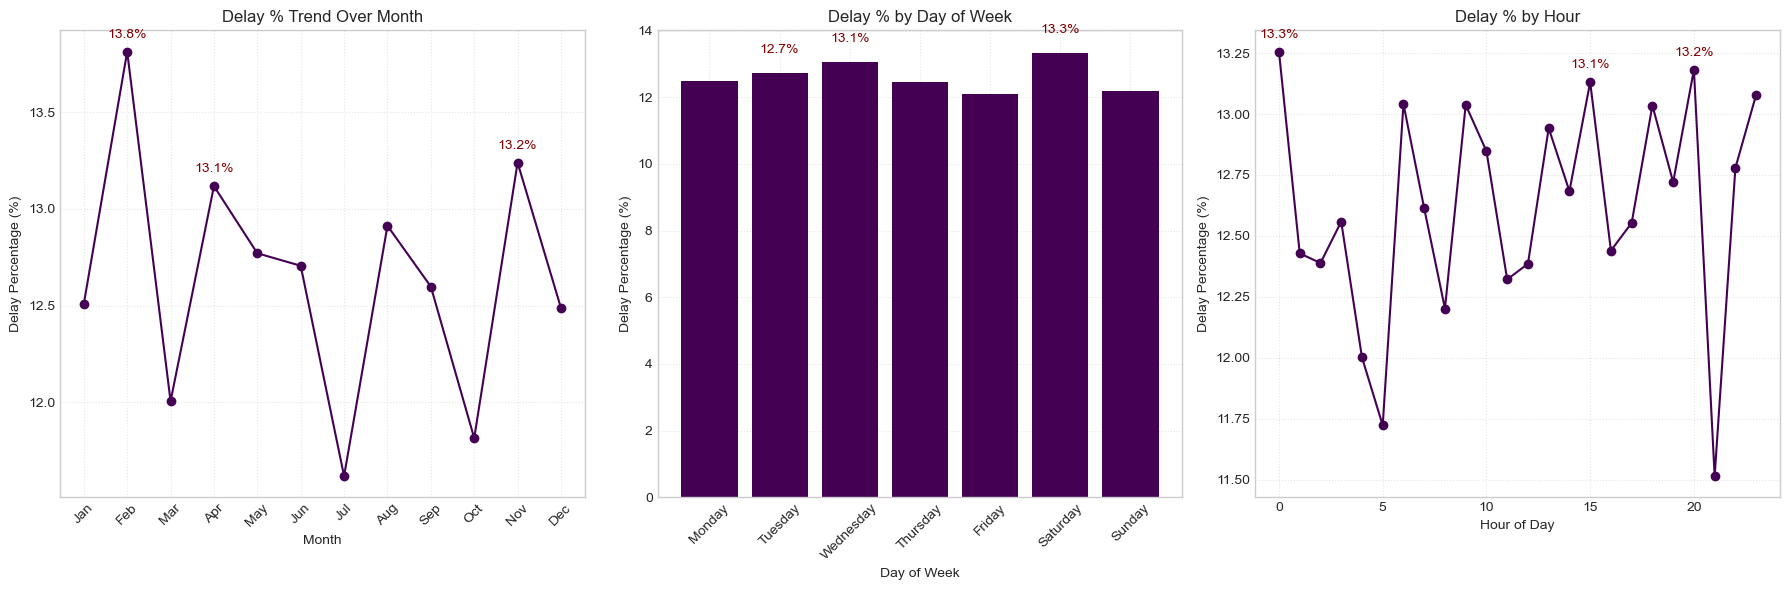

In [68]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)


# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )


# Subplot 2: Delay % by Day of Week
day_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(
    delay_by_day['order_day'],
    delay_by_day['delay_pct'],
    color=primary_color
)

ax2.set_xticklabels(
    delay_by_day['order_day'],
    rotation=45
)

ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(
        row['order_day'],
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )


# Subplot 3: Delay % by Hour
ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)


# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color)
plt.tight_layout()
plt.show()

**MACHINE LEARNING MODELING**

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , precision_score,recall_score,classification_report
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [76]:
X = df[['Type', 'Days for shipment (scheduled)', 'Category Name','Customer Segment', 'Department Name', 'Order Region','Shipping Mode','order_month','order_hour']]
y = df['Late_delivery_risk']

In [83]:
# Identify categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:',cat_cols)
# Frequency encoding
# Good for low-dimensional and high-cardinality categorical columns
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)
# Keep numeric columns + new encoded features
# Drop original string categorical columns
X_encoded = X.drop(columns=cat_cols)
print("Shape after freq + target encoding:", X_encoded.shape)
# Use encoded features for modeling
X = X_encoded
# Train / Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.2,random_state=42,stratify=y)

Categorical columns: []
Shape after freq + target encoding: (180519, 9)


In [93]:
print("Total NaN:", X_train.isna().sum().sum())
# Fill missing values in training data
X_train = X_train.fillna(X_train.median())

# Fill missing values in test data
X_test = X_test.fillna(X_train.median())
print("NaN in X_train:", X_train.isna().sum().sum())
print("NaN in X_test:", X_test.isna().sum().sum())

Total NaN: 0
NaN in X_train: 0
NaN in X_test: 0


In [94]:
y.value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

In [95]:


# Check class distribution before balancing
print("Before balancing (train):", Counter(y_train))

# Create SMOTE object
smote = SMOTE(random_state=42)

# Balance the training data
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check class distribution after balancing
print("After balancing (train):", Counter(y_train_bal))

Before balancing (train): Counter({1: 79181, 0: 65234})
After balancing (train): Counter({1: 79181, 0: 79181})


In [98]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n{'='*20} {model_name} {'='*20}")
    print("Accuracy:", round(accuracy_score(y_true, y_pred), 2))
    print("Precision:", round(precision_score(y_true, y_pred),2))
    print("Recall:", round(recall_score(y_true, y_pred),2))
    print("\nClassification Report:\n",classification_report(y_true, y_pred))

In [100]:
# Fit the Random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal,y_train_bal)
# Make predictions on the original test data
y_pred_rf_balanced = rf_model_balanced.predict(X_test)
# Evaluate the model
evaluate_model(y_test,y_pred_rf_balanced,"Random Forest Classifier")


==================== Random Forest Classifier ====================
Accuracy: 0.72
Precision: 0.78
Recall: 0.69

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.76      0.71     16308
           1       0.78      0.69      0.73     19796

    accuracy                           0.72     36104
   macro avg       0.72      0.72      0.72     36104
weighted avg       0.73      0.72      0.72     36104

